In [130]:
#Importamos las librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re

from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, make_scorer, classification_report,
    ConfusionMatrixDisplay, confusion_matrix, recall_score,
    accuracy_score, precision_score, roc_curve, RocCurveDisplay,
    PrecisionRecallDisplay, roc_auc_score, precision_recall_curve,
    mean_absolute_error
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.utils import shuffle
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import chi2




In [131]:
df = pd.read_csv('datasets/Churn.csv')

In [ ]:
var2 = 1 
var1 = 2 
var2 + var1 
var_booleano = False


In [132]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2.0,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1.0,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8.0,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1.0,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2.0,125510.82,1,1,1,79084.10,0


In [133]:
df.columns = (df.columns
                .str.replace('(?<=[a-z])(?=[A-Z])', '_', regex=True)
                .str.lower()
             )

In [134]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   row_number        10000 non-null  int64  
 1   customer_id       10000 non-null  int64  
 2   surname           10000 non-null  object 
 3   credit_score      10000 non-null  int64  
 4   geography         10000 non-null  object 
 5   gender            10000 non-null  object 
 6   age               10000 non-null  int64  
 7   tenure            9091 non-null   float64
 8   balance           10000 non-null  float64
 9   num_of_products   10000 non-null  int64  
 10  has_cr_card       10000 non-null  int64  
 11  is_active_member  10000 non-null  int64  
 12  estimated_salary  10000 non-null  float64
 13  exited            10000 non-null  int64  
dtypes: float64(3), int64(8), object(3)
memory usage: 1.1+ MB


In [135]:
df.drop(['row_number', 'customer_id', 'surname'], axis=1, inplace = True)

In [136]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
credit_score,10000.0,650.528800,96.653299,350.00,584.00,652.000,718.0000,850.00
age,10000.0,38.921800,10.487806,18.00,32.00,37.000,44.0000,92.00
tenure,9091.0,4.997690,2.894723,0.00,2.00,5.000,7.0000,10.00
balance,10000.0,76485.889288,62397.405202,0.00,0.00,97198.540,127644.2400,250898.09
num_of_products,10000.0,1.530200,0.581654,1.00,1.00,1.000,2.0000,4.00
has_cr_card,10000.0,0.705500,0.455840,0.00,0.00,1.000,1.0000,1.00
is_active_member,10000.0,0.515100,0.499797,0.00,0.00,1.000,1.0000,1.00
estimated_salary,10000.0,100090.239881,57510.492818,11.58,51002.11,100193.915,149388.2475,199992.48
exited,10000.0,0.203700,0.402769,0.00,0.00,0.000,0.0000,1.00


In [137]:
print("Valores ausentes", (len(df[df.tenure.isna()])/len(df)*100)," %")

Valores ausentes 9.09  %


In [138]:
df['tenure'].value_counts()

1.0     952
2.0     950
8.0     933
3.0     928
5.0     927
7.0     925
4.0     885
9.0     882
6.0     881
10.0    446
0.0     382
Name: tenure, dtype: int64

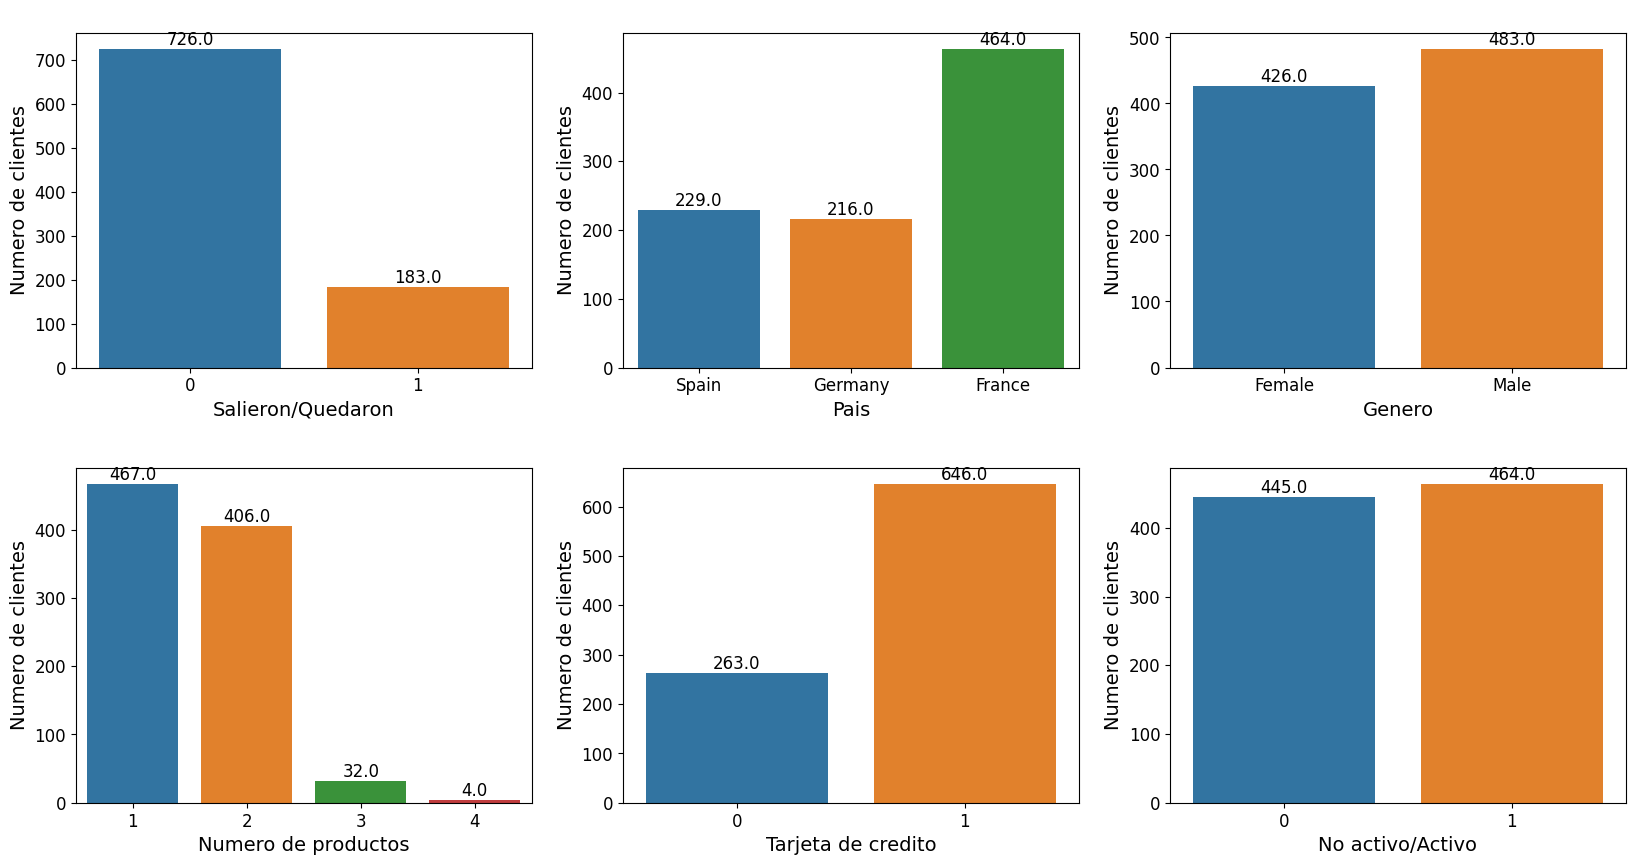

In [139]:
# Veamos las columnas con datos categoricos por la columna Tenure
plt.figure(figsize=(20,10))
plt.subplots_adjust(wspace=0.2, hspace=0.3)

columns = ['exited','geography', 'gender', 'num_of_products','has_cr_card','is_active_member']
x_titles = ['Salieron/Quedaron',
            'Pais',
            'Genero',
            'Numero de productos',
            'Tarjeta de credito',
            'No activo/Activo']

for i in range(len(columns)):
    fig = plt.subplot(2, 3, i+1)    
    ax = sns.countplot(data=df[df['tenure'].isna()==True], x=columns[i])
    plt.xlabel(x_titles[i], fontsize=14)
    plt.ylabel('Numero de clientes', fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    
    total = len(df[df['tenure'].isna()==True])
    for p in ax.patches:
        ax.annotate(f'\n{p.get_height()}',
                    (p.get_x()+0.4, p.get_height()),
                    color='black',
                    size=12,
                    ha='center',
                    va='bottom')

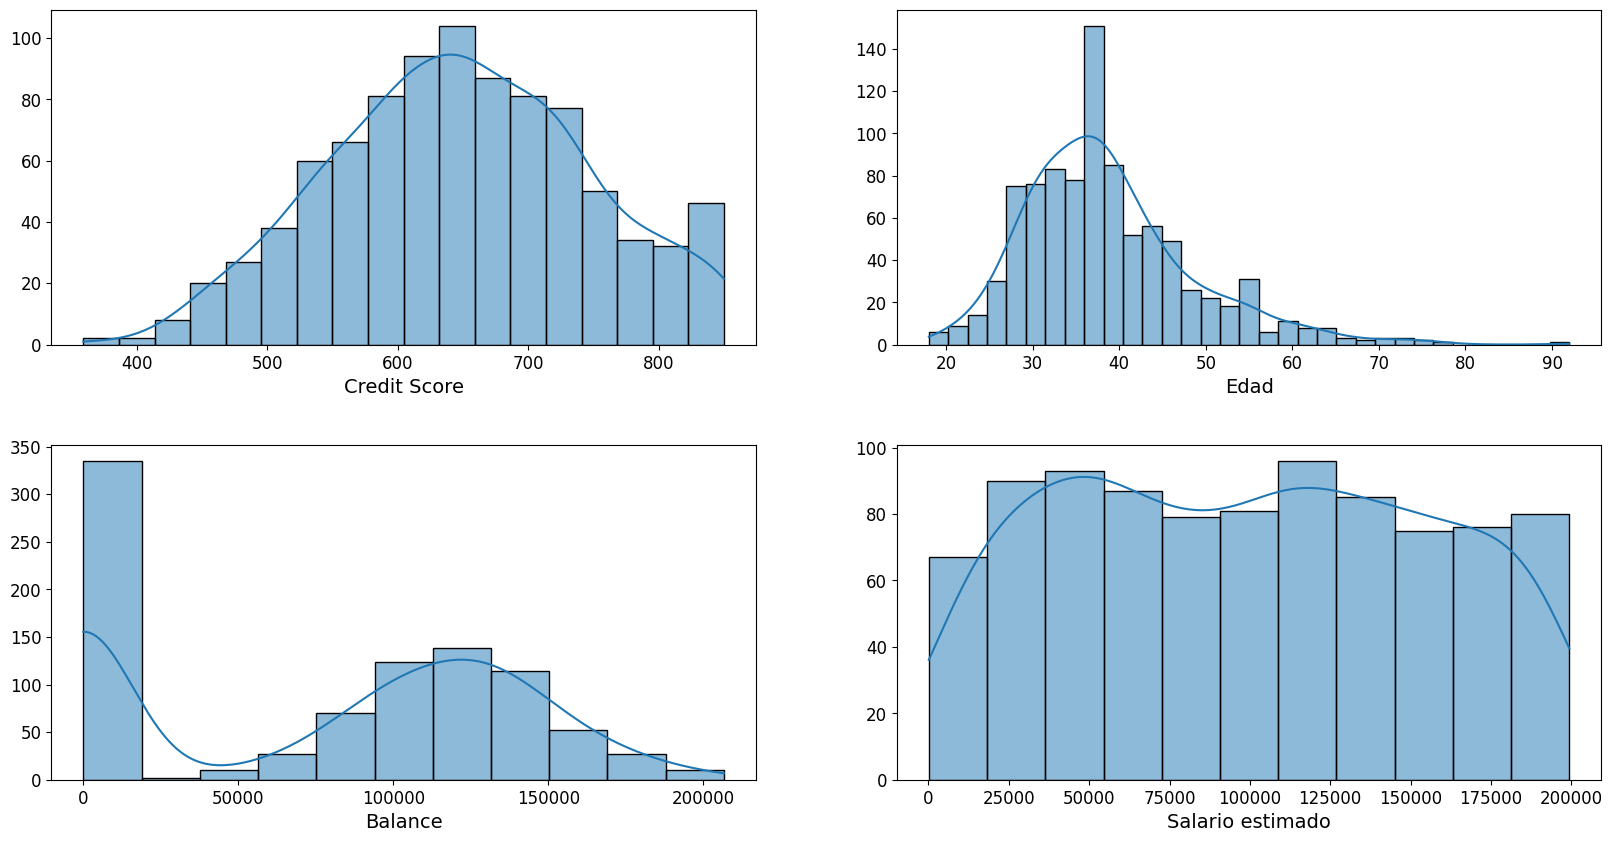

In [140]:
# Veamos las columnas con datos cuantativos

plt.figure(figsize=(20,10))
plt.subplots_adjust(wspace=0.2, hspace=0.3)

columns = list(df[df['tenure'].isna()==True][['credit_score', 'age', 'balance', 'estimated_salary']].columns)
x_titles = ['Credit Score',
            'Edad',
            'Balance',
            'Salario estimado']

for i in range(len(columns)):
    fig = plt.subplot(2, 2, i+1)    
    ax = sns.histplot(data=df[df['tenure'].isna()==True][['credit_score', 'age', 'balance', 'estimated_salary']], x=columns[i], kde=True)
    ax.set(ylabel=None)
    plt.xlabel(x_titles[i], fontsize=14)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

In [141]:
np.random.seed(42)
s = df.tenure.value_counts(normalize=True)
missing = df['tenure'].isnull()
df.loc[missing, 'tenure'] = np.random.choice(s.index, p=s.values, size=len(df[missing]))
df['tenure'] = df['tenure'].astype(int)
df

,credit_score,geography,gender,age,tenure,balance,num_of_products,has_cr_card,is_active_member,estimated_salary,exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


<Axes: >

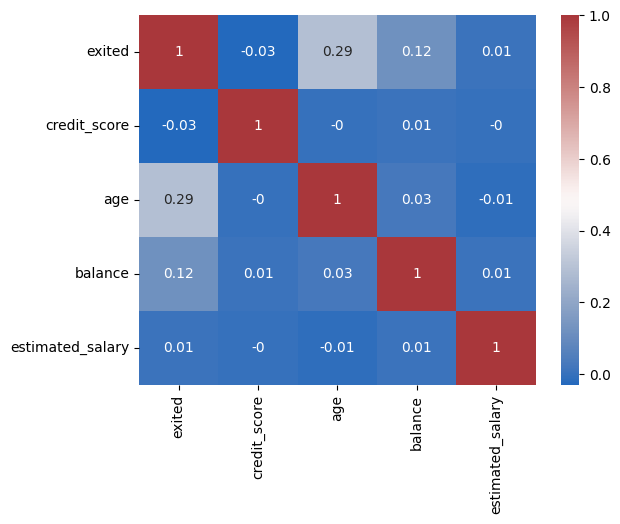

In [142]:
sns.heatmap(df[['exited','credit_score', 'age', 'balance', 'estimated_salary']].corr().round(2), annot=True, cmap='vlag')

In [143]:
le = LabelEncoder()
# Encode the categorical variables
df['geography_encoded'] = le.fit_transform(df['geography'])
df['gender_encoded'] = le.fit_transform(df['gender'])


f_p_values=chi2(df[['geography_encoded', 'gender_encoded', 'num_of_products','has_cr_card','is_active_member']], df['exited'])
categorical_features = pd.Series(f_p_values[1])
categorical_features.index = df[['geography_encoded', 'gender_encoded', 'num_of_products','has_cr_card','is_active_member']].columns
categorical_features.sort_index()

gender_encoded       7.015575e-13
geography_encoded    5.756078e-04
has_cr_card          6.984962e-01
is_active_member     1.568036e-27
num_of_products      2.454940e-02
dtype: float64

In [146]:
# Transformemos características categóricas en numéricas con OHE. 
# Dividimos los datos en dos conjuntos.
df_ohe = pd.get_dummies(df[['age','balance','is_active_member','geography','gender','exited']], drop_first=True)
target = df_ohe['exited']
features = df_ohe.drop('exited', axis=1)

features_train, features_valid, target_train, target_valid = train_test_split(features, target, test_size=.25, random_state=12345)

In [ ]:

# from sklearn.preprocessing import LabelEncoder
# from scipy.stats import chi2_contingency

# # Create a LabelEncoder object

# # Create the contingency table
# contingency_table = pd.crosstab([df['geography_encoded'], df['gender_encoded'], df['num_of_products'], df['has_cr_card'], df['is_active_member']], df['exited'])
# contingency_table

# statistic, p_value, dof, expected = chi2_contingency(contingency_table)

# # Print the results
# print("Chi-squared statistic:", statistic)
# print("p-value:", p_value)
# print("Degrees of freedom:", dof)
# print("Expected values:", expected)

In [153]:
# Tenemos que estandartizar features
numeric = list(features[['age','balance']].columns)

scaler = StandardScaler()
scaler.fit(features_train[numeric])
features_train[numeric] = scaler.transform(features_train[numeric])
features_valid[numeric] = scaler.transform(features_valid[numeric])


In [159]:
# Veamos el tamaño de conjuntos
for col in ['features_train', 'target_train', 'features_valid', 'target_valid']:
    print(f'Tamaño del conjunto {col} : {locals()[col].shape}')

Tamaño del conjunto features_train : (7500, 6)
Tamaño del conjunto target_train : (7500,)
Tamaño del conjunto features_valid : (2500, 6)
Tamaño del conjunto target_valid : (2500,)


In [160]:
# Entrenemos el modelo sin tener en cuenta el desequilibrio con el modelo del Arbol de Decision
model = DecisionTreeClassifier(random_state=12345)
model.fit(features_train, target_train)
predicted_valid = model.predict(features_valid)

accuracy_valid = accuracy_score(target_valid, predicted_valid) 

print('Accuracy', accuracy_valid)

Accuracy 0.7644


0    0.7963
1    0.2037
Name: exited, dtype: float64


<Axes: >

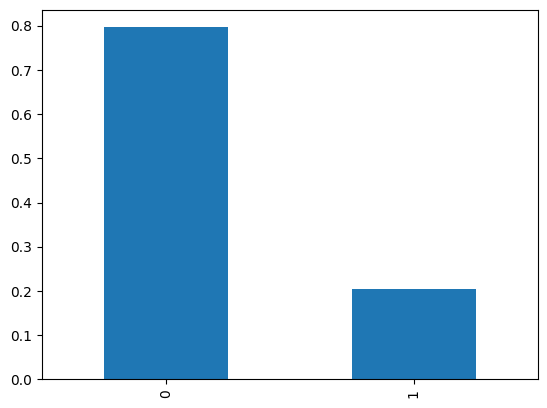

In [161]:
#La exactitud no es muy alta. Mostraremos graficamente el equilibrio de clases de dataset
class_frequency = df['exited'].value_counts(normalize=True)
print(class_frequency)
class_frequency.plot(kind='bar') 

0    0.8152
1    0.1848
dtype: float64


<Axes: >

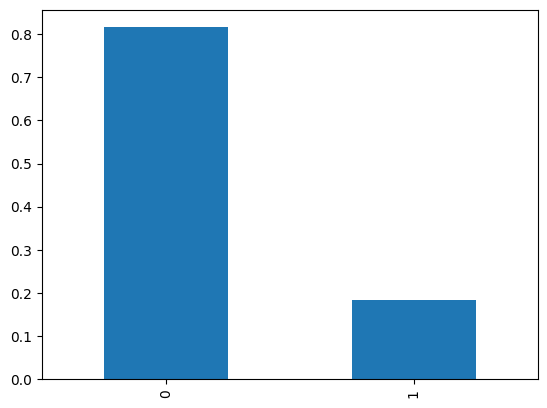

In [162]:
# Analisemos las frecuencias de clase de las predicciones del árbol de decisión 
model = DecisionTreeClassifier(random_state=12345)
model.fit(features_train, target_train)
predicted_valid = pd.Series(model.predict(features_valid))

class_frequency = predicted_valid.value_counts(normalize=True)
print(class_frequency)
class_frequency.plot(kind='bar')

In [163]:
# Creemos un modelo constante: predice la clase "0" para cualquier observación. Muestramos el valor de accuracy
target_pred_constant = pd.Series(0, index=target.index)

print('Accuracy ', accuracy_score(target, target_pred_constant))

Accuracy  0.7963


In [164]:
# Matriz de confusion
print('Matriz de confusion')
print(confusion_matrix(target_valid, predicted_valid))
# Recall
print('Recall', recall_score(target_valid, predicted_valid))
# Precision
print('Precision', precision_score(target_valid, predicted_valid))
# F1
print('F1', f1_score(target_valid, predicted_valid))

Matriz de confusion
[[1707  258]
 [ 331  204]]
Recall 0.3813084112149533
Precision 0.44155844155844154
F1 0.4092276830491474


In [165]:
#Entrenemos el modelo sin tener en cuenta el desequilibrio con el modelo del Arbol de Decision variando max_depth
depth_range = range(1, 30)
f1_list=[]
auc_list=[]

for depth in depth_range:
    model = DecisionTreeClassifier(random_state=12345, max_depth=depth) 
    model.fit(features_train, target_train) 
    predicted_valid = model.predict(features_valid) 
    f1_list.append(f1_score(target_valid, predicted_valid).round(3)) 
    probabilities_valid = model.predict_proba(features_valid) 
    probabilities_one_valid = probabilities_valid[:, 1] 
    auc_list.append(roc_auc_score(target_valid, probabilities_one_valid).round(3)) 
    
tree_df = pd.DataFrame({'max_depth': list(depth_range), 'f1':f1_list, 'AUC-ROC':auc_list})
tree_df.sort_values(by='f1', ascending=False).reset_index(drop=True).head(3)

,max_depth,f1,AUC-ROC
0,5,0.490,0.784
1,7,0.486,0.784
2,2,0.482,0.743


In [166]:
# Entrenamiento para un modelo de regresión logística con clases igualmente ponderadas. 
# Equilibremos los pesos de clase pasando el valor de argumento adecuado para class_weight. Observemos cómo cambia el valor F1.
LogRegBalanced = LogisticRegression(random_state=12345, class_weight='balanced', solver='liblinear')
LogRegBalanced.fit(features_train, target_train)
predicted_valid = LogRegBalanced.predict(features_valid)
print('F1:', f1_score(target_valid, predicted_valid))

F1: 0.5134408602150538
